PyTorch version: 2.11.0+cu130
CUDA available: True

--- One-Class PyTorch Model - NATIVE GPU (CUDA) ---
[*] Date încărcate pentru antrenare (Benigne 2017): 345659 rânduri.
[*] Date încărcate pentru testare (Total 2017): 100250 rânduri.
[*] Date test incarcate din faza de preprocesare: 86415 Normale, 13835 Anomalii.
Antrenare în curs pe GPU folosind PyTorch (345659 rânduri)...

RAPORT FINAL:
 SISTEM AUDIT - REZULTATE ONE-CLASS PYTORCH GPU (OPTIMIZAT DETECTIE)
Scor AUC: 0.6375
Timp Antrenare GPU: 9.76s
              precision    recall  f1-score   support

      Normal       0.95      0.28      0.43     86415
    Anomalie       0.17      0.91      0.28     13835

    accuracy                           0.36    100250
   macro avg       0.56      0.59      0.36    100250
weighted avg       0.84      0.36      0.41    100250



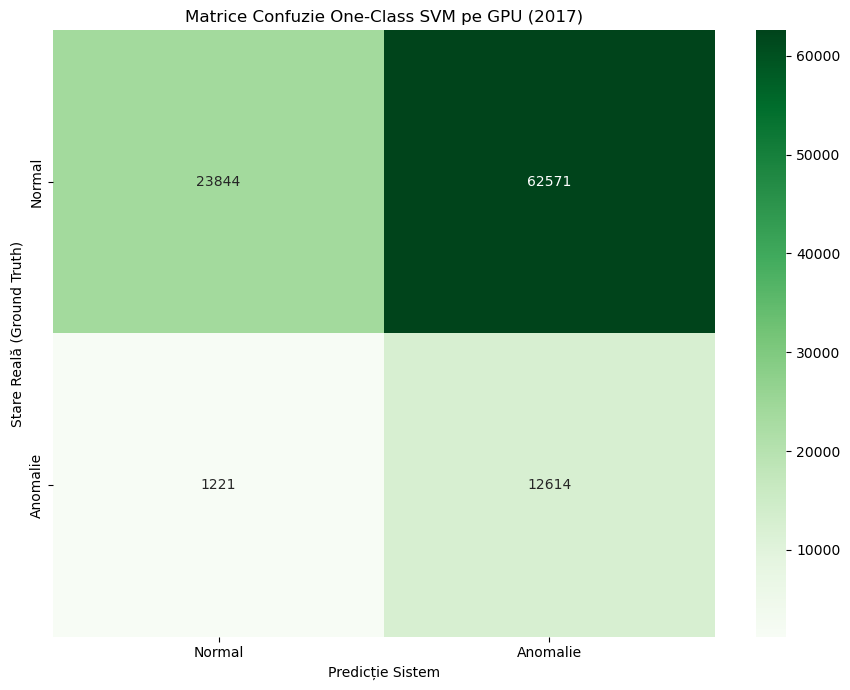

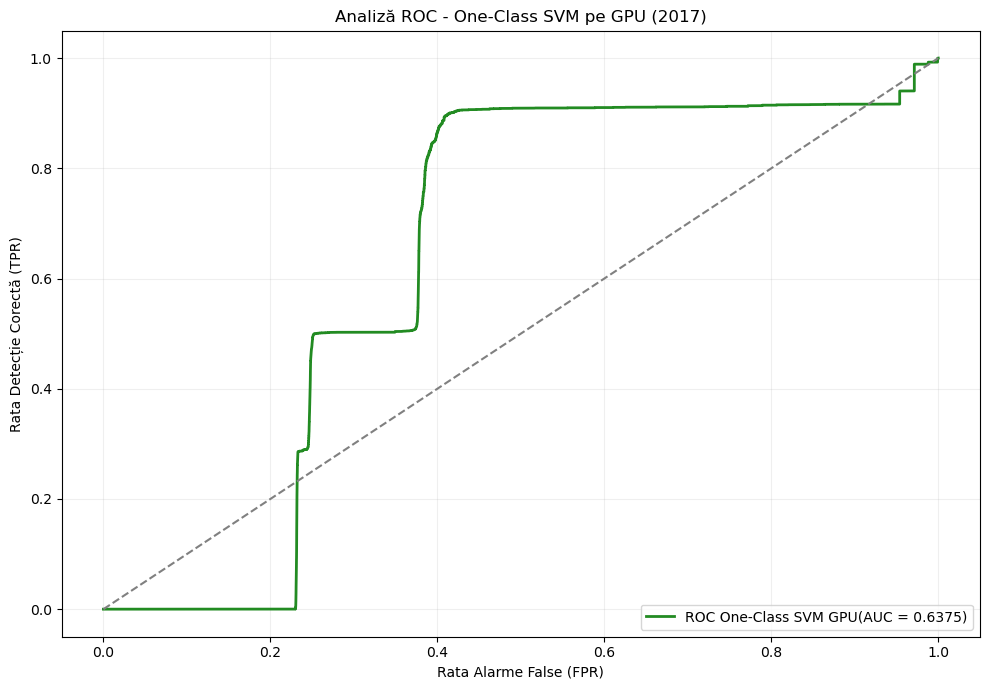

In [ ]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    print("EROARE: Nu s-a detectat GPU! Trecem pe CPU.")
    device = torch.device("cpu")

prepro_path = r'D:\disertatie\preprocesare_anomalii_2017'
model_save_path = r'D:\disertatie\modele_2017\One_class_SVM'
rezultate_path = r'D:\disertatie\rezultate_2017\One_class_SVM'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("\n--- One-Class PyTorch Model - NATIVE GPU (CUDA) ---")

X_train_raw = torch.load(os.path.join(prepro_path, 'X_train_anomalii.pt')).to(device)
X_test_raw = torch.load(os.path.join(prepro_path, 'X_test_anomalii.pt')).to(device)
y_test_tensor = torch.load(os.path.join(prepro_path, 'y_test_anomalii.pt')).to(device)
print(f"[*] Date încărcate pentru antrenare (Benigne 2017): {X_train_raw.shape[0]} rânduri.")
print(f"[*] Date încărcate pentru testare (Total 2017): {X_test_raw.shape[0]} rânduri.")
num_normale_test = int((y_test_tensor == 0).sum().item())
num_anomalii_test = int((y_test_tensor == 1).sum().item())
print(f"[*] Date test incarcate din faza de preprocesare: {num_normale_test} Normale, {num_anomalii_test} Anomalii.")

mean = X_train_raw.mean(dim=0)
std = X_train_raw.std(dim=0)
std[std == 0] = 1.0

X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

class PyTorchOneClassSVM(nn.Module):
    def __init__(self, input_dim):
        super(PyTorchOneClassSVM, self).__init__()
        self.w = nn.Parameter(torch.randn(input_dim, 1) * 0.01)
        self.rho = nn.Parameter(torch.zeros(1))
        
    def forward(self, x):
        return torch.matmul(x, self.w) - self.rho

input_dim = X_train.shape[1]
model = PyTorchOneClassSVM(input_dim).to(device)

nu = 0.05
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 150
batch_size = 8192

start_time = time.time()
print(f"Antrenare în curs pe GPU folosind PyTorch ({len(X_train)} rânduri)...")

model.train()
num_samples = X_train.shape[0]

for epoch in range(epochs):
    permutation = torch.randperm(num_samples)
    
    for i in range(0, num_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_train[indices]
        
        optimizer.zero_grad()
        scores = model(batch_x)
        
        hinge_loss = torch.mean(torch.clamp(1.0 - scores, min=0.0))
        reg_loss = 0.5 * torch.sum(model.w ** 2)
        loss = reg_loss + (1.0 / nu) * hinge_loss - model.rho
        
        loss.backward()
        optimizer.step()

train_time = time.time() - start_time


torch.save(model.state_dict(), os.path.join(model_save_path, 'pytorch_ocsvm_gpu.pkl'))

model.eval()
with torch.no_grad():
    test_scores = model(X_test).squeeze().cpu().numpy()

y_test = y_test_tensor.cpu().numpy()

percentila_dorita = 75
prag_dinamic = np.percentile(test_scores, percentila_dorita)
y_pred = (test_scores < prag_dinamic).astype(int)

y_scores = -test_scores
if confusion_matrix(y_test, y_pred)[0, 0] == 0:
    y_pred = 1 - y_pred
    y_scores = -y_scores

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie'])
full_text = f"SISTEM AUDIT - REZULTATE ONE-CLASS PYTORCH GPU (OPTIMIZAT DETECTIE)\n"
full_text += f"Scor AUC: {roc_auc:.4f}\n"
full_text += f"Timp Antrenare GPU: {train_time:.2f}s\n"
full_text += "="*50 + "\n"
full_text += report

print("\nRAPORT FINAL:\n", full_text)
with open(os.path.join(rezultate_path, 'raport_final_ocsvm_gpu.txt'), 'w') as f:
    f.write(full_text)

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.title('Matrice Confuzie One-Class SVM pe GPU (2017)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ocsvm_gpu.png'), dpi=300)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='forestgreen', lw=2, label=f'ROC One-Class SVM GPU(AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Analiză ROC - One-Class SVM pe GPU (2017)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ocsvm_gpu.png'), dpi=300)

plt.show()